🔧 Code Implementation

Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


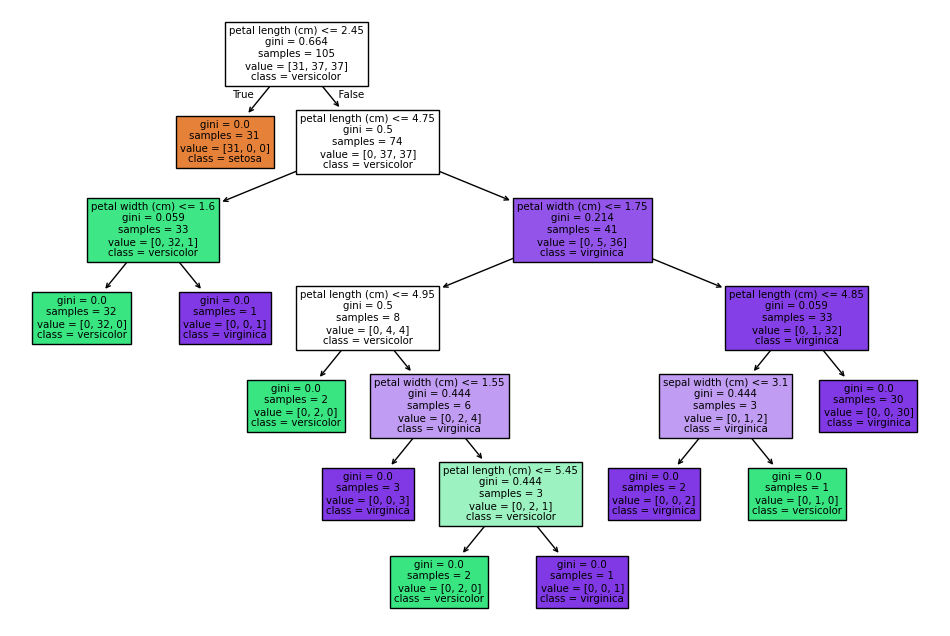

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Prediction
y_pred = clf.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)

# Visualize tree
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


Task 1: Random Forest on Iris

Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


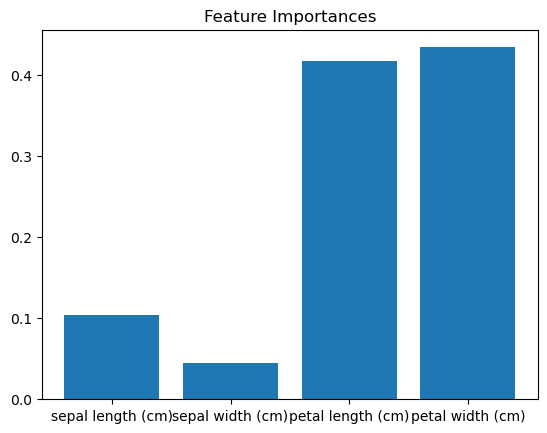

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature importance
plt.bar(iris.feature_names, rf.feature_importances_)
plt.title("Feature Importances")
plt.show()


Task 2: Effect of n_estimators

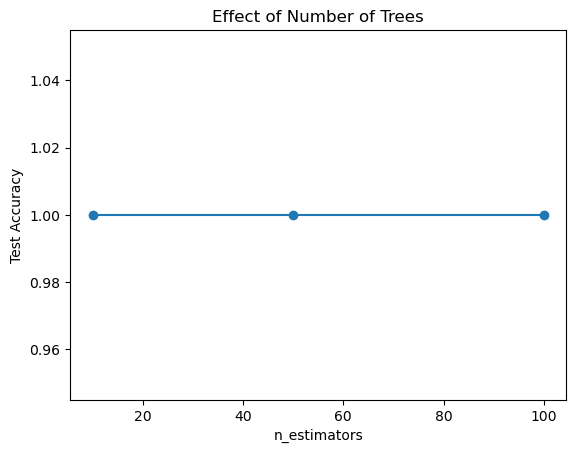

In [7]:
estimators = [10, 50, 100]
scores = []

for n in estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    scores.append(rf.score(X_test, y_test))

plt.plot(estimators, scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Test Accuracy")
plt.title("Effect of Number of Trees")
plt.show()


Task 3: Compare Random Forest vs Decision Tree

| Model         | Accuracy            | Overfitting | Stability |
| ------------- | ------------------- | ----------- | --------- |
| Decision Tree | High but unstable   | High        | Low       |
| Random Forest | Higher & consistent | Low         | High      |


In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------------
# Decision Tree Classifier
# -----------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_cm = confusion_matrix(y_test, dt_pred)

print("=== Decision Tree Results ===")
print("Accuracy:", dt_acc)
print("Confusion Matrix:\n", dt_cm)

# -----------------------------
# Random Forest Classifier
# -----------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print("\n=== Random Forest Results ===")
print("Accuracy:", rf_acc)
print("Confusion Matrix:\n", rf_cm)

# -----------------------------
# Final Comparison
# -----------------------------
print("\n=== Comparison Summary ===")
print(f"Decision Tree Accuracy:  {dt_acc}")
print(f"Random Forest Accuracy: {rf_acc}")

if rf_acc > dt_acc:
    print("Random Forest wins — more stable, less overfitting.")
elif rf_acc < dt_acc:
    print("Decision Tree wins — unlucky split, but acceptable.")
else:
    print("Both models tie — rare but possible.")


=== Decision Tree Results ===
Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

=== Random Forest Results ===
Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

=== Comparison Summary ===
Decision Tree Accuracy:  1.0
Random Forest Accuracy: 1.0
Both models tie — rare but possible.


✅ Random Forest With OOB Error (Full Code)

In [10]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Random Forest with OOB score enabled
rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,         # <<< THIS IS THE MAGIC
    bootstrap=True,         # MUST be True for OOB to work
    random_state=42
)

# Train model
rf.fit(X, y)

# Predictions (using all data, but OOB score acts like internal validation)
y_pred = rf.predict(X)

# Outputs
print("OOB Score (Internal Validation Accuracy):", rf.oob_score_)
print("Training Accuracy:", accuracy_score(y, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

# Feature Importances
print("\nFeature Importances:")
for name, importance in zip(iris.feature_names, rf.feature_importances_):
    print(f"{name}: {importance:.4f}")


OOB Score (Internal Validation Accuracy): 0.9533333333333334
Training Accuracy: 1.0
Confusion Matrix:
 [[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]

Feature Importances:
sepal length (cm): 0.1061
sepal width (cm): 0.0217
petal length (cm): 0.4361
petal width (cm): 0.4361


OOB Error vs Number of Trees

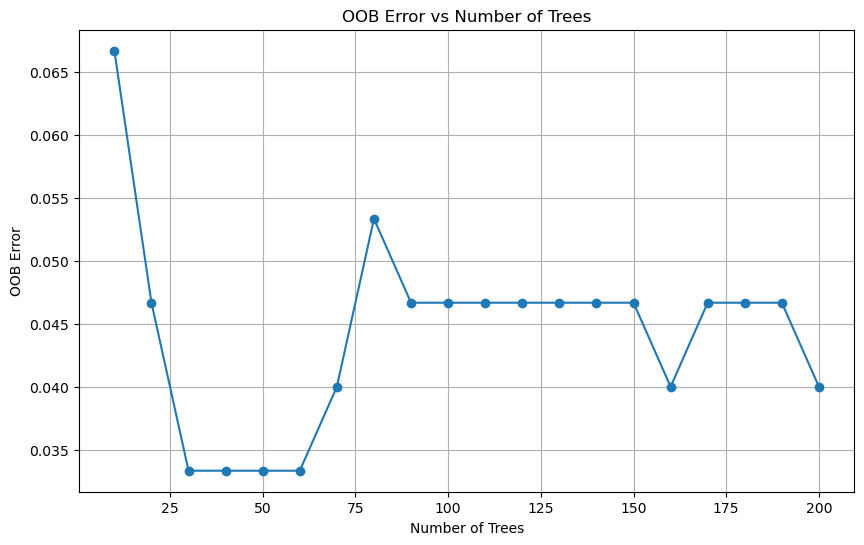

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

# ---------------------------------------
# Load Dataset (Iris — replace with yours)
# ---------------------------------------
data = load_iris()
X = data.data
y = data.target

# ---------------------------------------
# Track OOB Error for Different Tree Counts
# ---------------------------------------
tree_counts = range(10, 201, 10)  # 10 to 200 trees
oob_errors = []

for n in tree_counts:
    model = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        bootstrap=True,
        random_state=42
    )
    model.fit(X, y)
    oob_error = 1 - model.oob_score_
    oob_errors.append(oob_error)

# ---------------------------------------
# Plot OOB Error Curve
# ---------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(tree_counts, oob_errors, marker='o')
plt.title("OOB Error vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.grid(True)
plt.show()
